In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../../Data Capsule/ROUND_1/trades_round_1_day_-1.csv", sep=";")
prices = pd.read_csv("../../../Data Capsule/ROUND_1/prices_round_1_day_-1.csv", sep=";")

# filter
osmium = df[df["symbol"] == "ASH_COATED_OSMIUM"].copy()
prices = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()


# sort
osmium = osmium.sort_values("timestamp")
prices = prices.sort_values("timestamp")

# robust merge
osmium = pd.merge_asof(
    osmium,
    prices[["timestamp", "mid_price"]],
    on="timestamp",
    direction="backward"
)

# classify trades
osmium["buy_volume"] = np.where(osmium["price"] >= osmium["mid_price"], osmium["quantity"], 0)
osmium["sell_volume"] = np.where(osmium["price"] < osmium["mid_price"], osmium["quantity"], 0)

# set index
# osmium = osmium.set_index("timestamp")

# resample
# resampled = osmium.resample("200ms").agg({
#     "price": "last",
#     "quantity": "sum",
#     "buy_volume": "sum",
#     "sell_volume": "sum"
# })
bin_size = 5000   # try 1000–5000 depending on density
osmium["time_bin"] = (osmium["timestamp"] // bin_size) * bin_size; 

resampled = osmium.groupby("time_bin").agg({
    "price": "last",
    "quantity": "sum",
    "buy_volume": "sum",
    "sell_volume": "sum"
}).reset_index()
resampled["price"] = resampled["price"].ffill()
# fix NaNs properly
resampled["price"] = resampled["price"].ffill()
resampled["quantity"] = resampled["quantity"].fillna(0)
resampled["buy_volume"] = resampled["buy_volume"].fillna(0)
resampled["sell_volume"] = resampled["sell_volume"].fillna(0)


print(resampled.head())
print(resampled["quantity"].sum())
print(len(resampled))

   time_bin    price  quantity  buy_volume  sell_volume
0         0   9985.0        10           0           10
1      5000  10004.0        31          22            9
2     10000  10007.0        12          12            0
3     15000  10008.0        15           8            7
4     20000  10010.0        13          11            2
2225
172


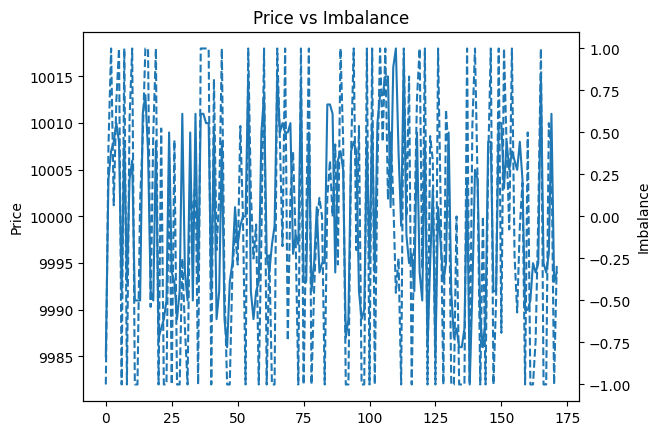

In [2]:
# PLOT 1 ORDER FLOW IMBALANCE VS PRICE
df = resampled.copy()

df["imbalance"] = (
    df["buy_volume"] - df["sell_volume"]
) / (df["buy_volume"] + df["sell_volume"] + 1e-9)

df = df.dropna()

fig, ax1 = plt.subplots()

ax1.plot(df.index, df["price"])
ax1.set_ylabel("Price")

ax2 = ax1.twinx()
ax2.plot(df.index, df["imbalance"], linestyle="dashed")
ax2.set_ylabel("Imbalance")

plt.title("Price vs Imbalance")
plt.show()

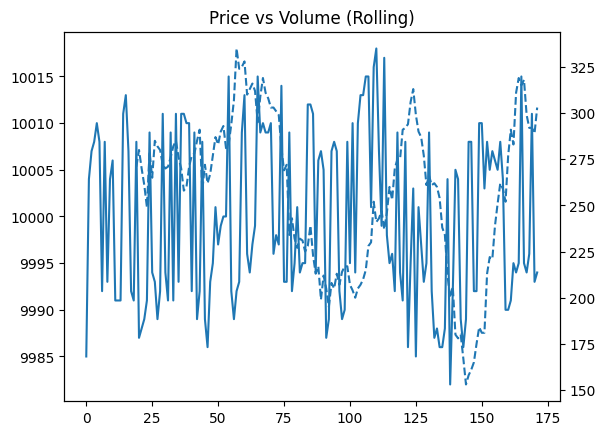

In [3]:
#PLOT 2 VOLUME SPIKES VS PRICE
window = 20
df["vol_rolling"] = df["quantity"].rolling(window).sum()

fig, ax1 = plt.subplots()

ax1.plot(df.index, df["price"])

ax2 = ax1.twinx()
ax2.plot(df.index, df["vol_rolling"], linestyle="dashed")

plt.title("Price vs Volume (Rolling)")
plt.show()

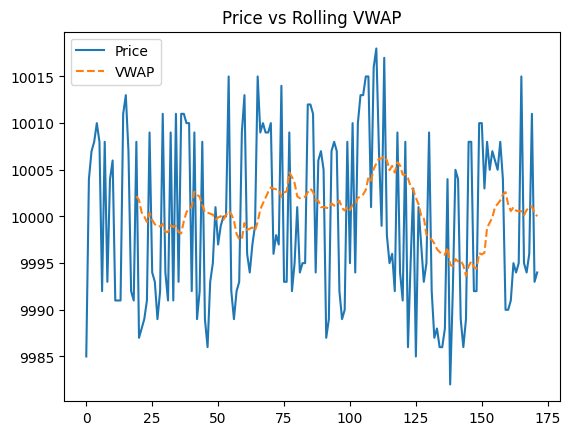

In [4]:
# PLOT 3 VWAP VS PRICE
window = 20

df["vwap"] = (
    (df["price"] * df["quantity"]).rolling(window).sum() /
    (df["quantity"].rolling(window).sum() + 1e-9)
)

plt.figure()
plt.plot(df.index, df["price"], label="Price")
plt.plot(df.index, df["vwap"], linestyle="dashed", label="VWAP")

plt.legend()
plt.title("Price vs Rolling VWAP")
plt.show()

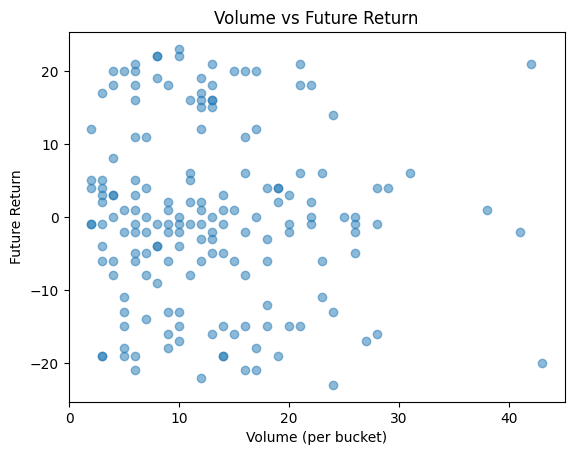

In [5]:
# plot 4 Trade Size vs Price Impact
# future return over next k buckets
k = 3
df["future_return"] = df["price"].shift(-k) - df["price"]

plt.figure()
plt.scatter(df["quantity"], df["future_return"], alpha=0.5)

plt.xlabel("Volume (per bucket)")
plt.ylabel("Future Return")
plt.title("Volume vs Future Return")
plt.show()

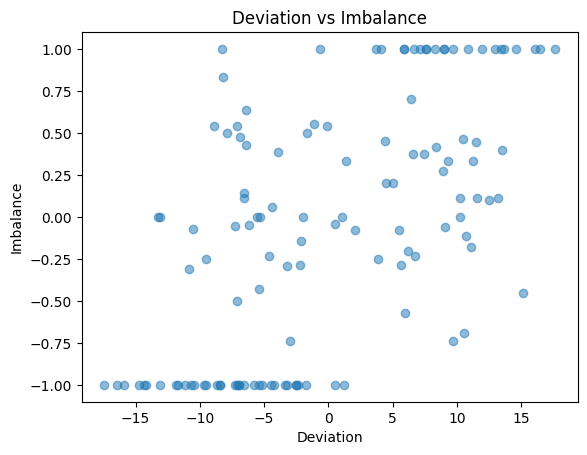

In [6]:
# PLOT 5 DEVIATION FROM MA VS IMBALANCE
# moving average from trades (or use prices.csv MA)
window = 50

df["ma"] = df["price"].rolling(window).mean()
df["deviation"] = df["price"] - df["ma"]

plt.figure()
plt.scatter(df["deviation"], df["imbalance"], alpha=0.5)

plt.xlabel("Deviation")
plt.ylabel("Imbalance")
plt.title("Deviation vs Imbalance")
plt.show()

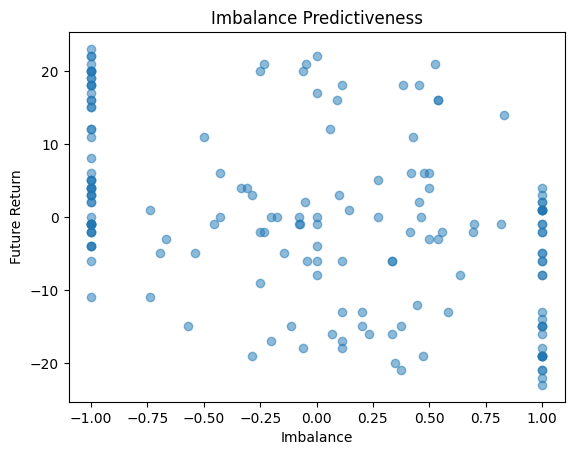

In [7]:
k = 3
df["future_return"] = df["price"].shift(-k) - df["price"]

plt.figure()
plt.scatter(df["imbalance"], df["future_return"], alpha=0.5)

plt.xlabel("Imbalance")
plt.ylabel("Future Return")
plt.title("Imbalance Predictiveness")
plt.show()